# 📈 Sales & Demand Forecasting Using Machine Learning
### Machine Learning Task 1 (2026) — Future Interns

* **Import Libraries**
* **Data Cleaning**
* **Feature Engineering**
* **Model Training**
* **Forecasting**
* **Visualization**
* **Business Insights**
* **Conclusion**

📈 Sales Trend
📊 Data Visualization
🤖 Machine Learning Model
🔮 Future Forecast
✅ Conclusion

# **1.** **Install Required Libraries**

In [ ]:
!pip install pandas numpy matplotlib scikit-learn

# **2.** **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


# **3.** **Load Dataset**

In [ ]:
df = pd.read_csv('/Sample - Superstore.csv', encoding='cp1252')

# **# Display dataset**

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **4.** **Understand Dataset**

# **#Dataset columns**

In [ ]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


# **5.** **Check Dataset Information**

# **# Dataset information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# **6.** **Check Missing Values**

# **# Missing values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# **7.** **Remove Missing Values**

# **# Remove null values**

In [ ]:
df.dropna(inplace=True)

# **#Verify again:**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# **8.** **Convert Date Column**

**Convert order date into datetime format.**
# Convert date column

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# **Create year feature**

In [ ]:
df['Year'] = df['Order Date'].dt.year

# **Create Month feature**

In [ ]:
df['Month'] = df['Order Date'].dt.month

# **Create Day feature**

In [ ]:
df['Day'] = df['Order Date'].dt.day

# **Create Weekday feature**

In [ ]:
df['Weekday'] = df['Order Date'].dt.weekday

# **9.** **View Updated Dataset**

# **# Display updated dataset**

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,Weekday
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,1
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,1
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,6
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11,6


# **10.** **Monthly Sales Aggregation**

# **We now group total sales month-wise.**

# #Monthly sales grouping

In [ ]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# **#Convert to dataframe**

In [ ]:
monthly_sales = monthly_sales.reset_index()

# **11.** **Convert Date Format**

In [ ]:
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])

# **12.** **Display Monthly Sales**

In [ ]:
monthly_sales.head()

,Order Date,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


# **13.** **Create Time Index**

# **Machine learning requires numerical input.**

# #Create time feature

In [ ]:
monthly_sales['Time'] = np.arange(len(monthly_sales))

# **#Display dataset:**

In [ ]:
monthly_sales.head()

,Order Date,Sales,Time
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


# **14.** **Visualize Monthly Sales**

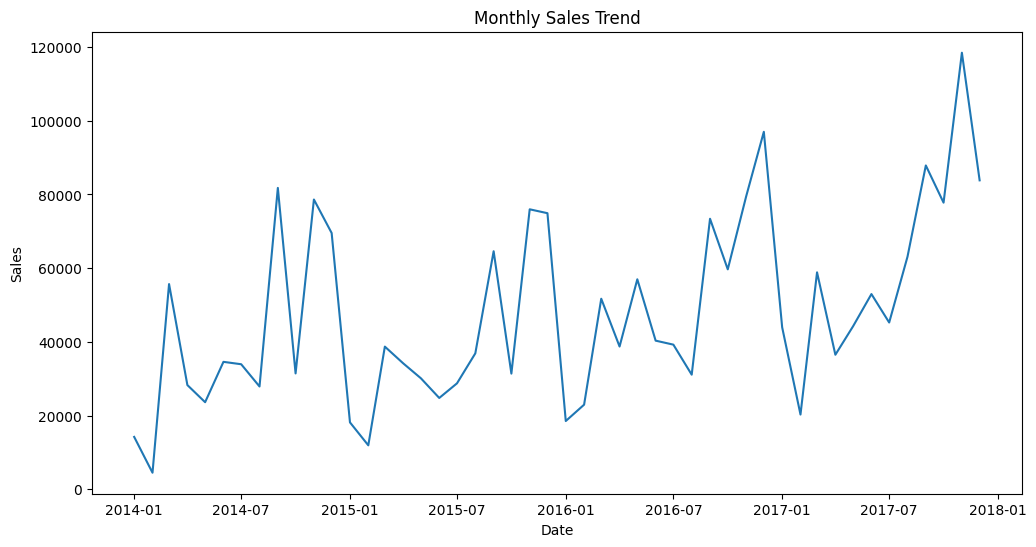

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

# **15.** **Prepare Training Data**

Input Feature

In [ ]:
X = monthly_sales[['Time']]

Target variable:

In [ ]:
y = monthly_sales['Sales']

# **Split Dataset**
#We split data into:


**#Training data**

**#Testing data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# **16.** **Train Machine Learning Model**

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

**#Compare Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

comparison

,Actual Sales,Predicted Sales
38,58872.3528,56490.056556
39,36521.5361,57189.603164
40,44261.1102,57889.149772
41,52981.7257,58588.696380
42,45264.4160,59288.242988
43,63120.8880,59987.789597
44,87866.6520,60687.336205
45,77776.9232,61386.882813
46,118447.8250,62086.429421
47,83829.3188,62785.976029


# **17.** **Evaluate Model Performance**

**#Mean Absolute Error (MAE)**

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print('MAE:', mae)

MAE: 18041.639348494362


**#Root Mean Squared Error (RMSE)**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print('RMSE:', rmse)

RMSE: 23416.378372719904


# **18.** **Visualize Actual vs Predicted Sales**

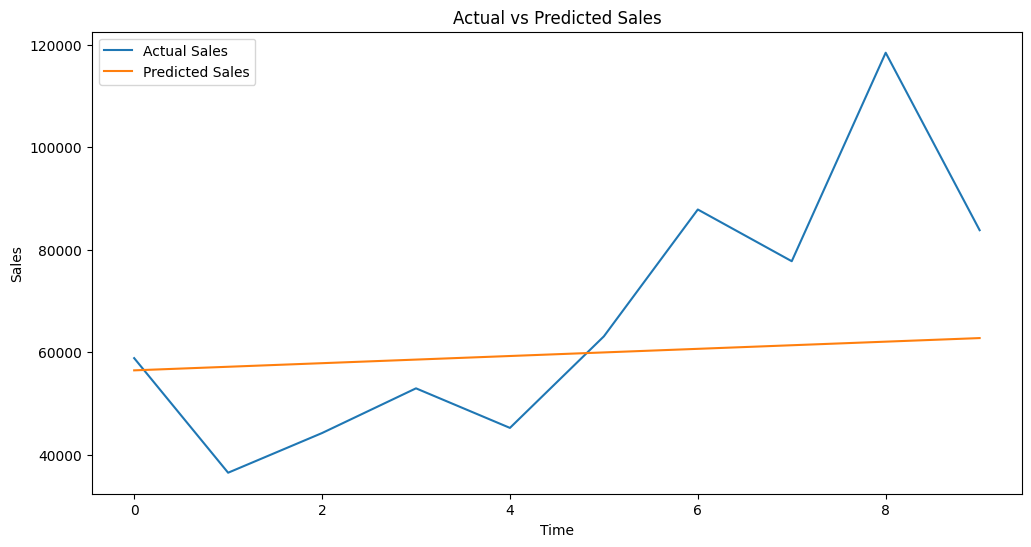

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Time')
plt.ylabel('Sales')

plt.legend()

plt.show()

# **19.** **Forecast Future Sales**

**#Now predict future sales for next 12 months.**


In [ ]:
future_time = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 12
).reshape(-1,1)

**#Predict future:**


In [ ]:
future_predictions = model.predict(future_time)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# **20.** **Display Future Predictions**

In [ ]:
future_predictions

array([63485.5226372 , 64185.06924533, 64884.61585346, 65584.16246159,
       66283.70906972, 66983.25567785, 67682.80228598, 68382.34889411,
       69081.89550224, 69781.44211037, 70480.9887185 , 71180.53532663])

# **21.** **Plot Future Forecast**

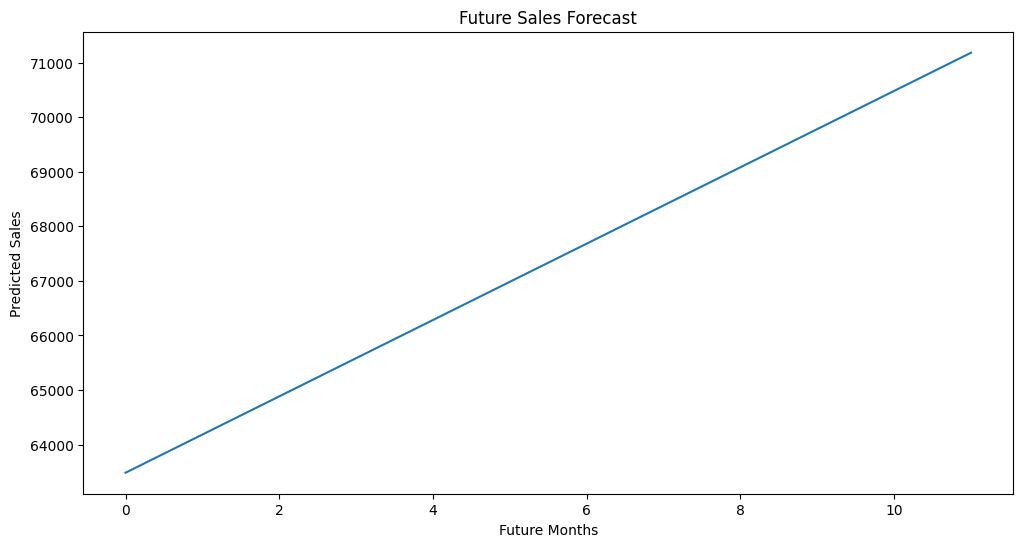

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(future_predictions)

plt.title('Future Sales Forecast')
plt.xlabel('Future Months')
plt.ylabel('Predicted Sales')

plt.show()

# **22.** **Create Future Forecast Table**

In [ ]:
future_df = pd.DataFrame({
    'Future Month': range(1,13),
    'Predicted Sales': future_predictions
})

future_df

,Future Month,Predicted Sales
0,1,63485.522637
1,2,64185.069245
2,3,64884.615853
3,4,65584.162462
4,5,66283.709070
5,6,66983.255678
6,7,67682.802286
7,8,68382.348894
8,9,69081.895502
9,10,69781.442110


# **23.** **Display Category Sales**

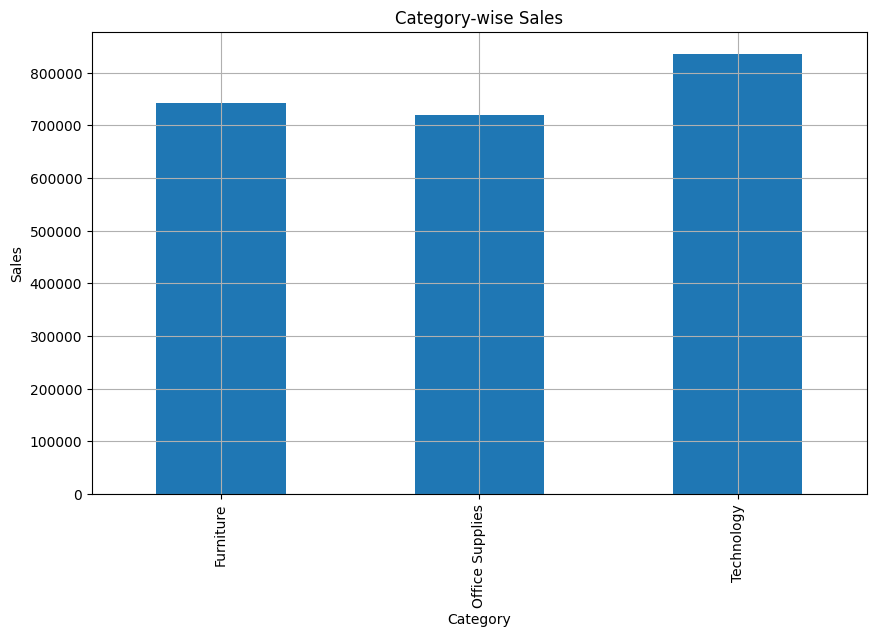

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10,6))

category_sales.plot(
    kind='bar'
)

plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

# **24.** **Display Regional Sales**

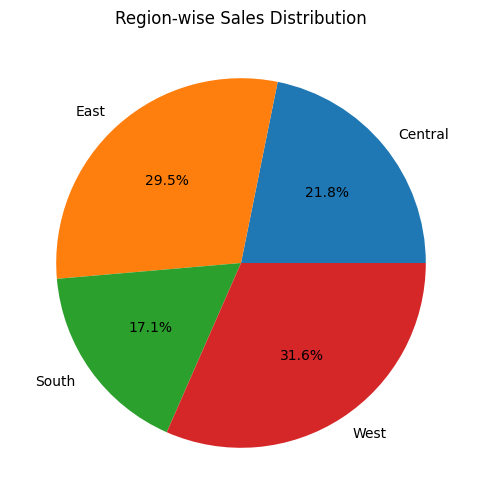

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10,6))

region_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Region-wise Sales Distribution')

plt.ylabel('')

plt.show()

# **25.** **Display Sales vs profit**

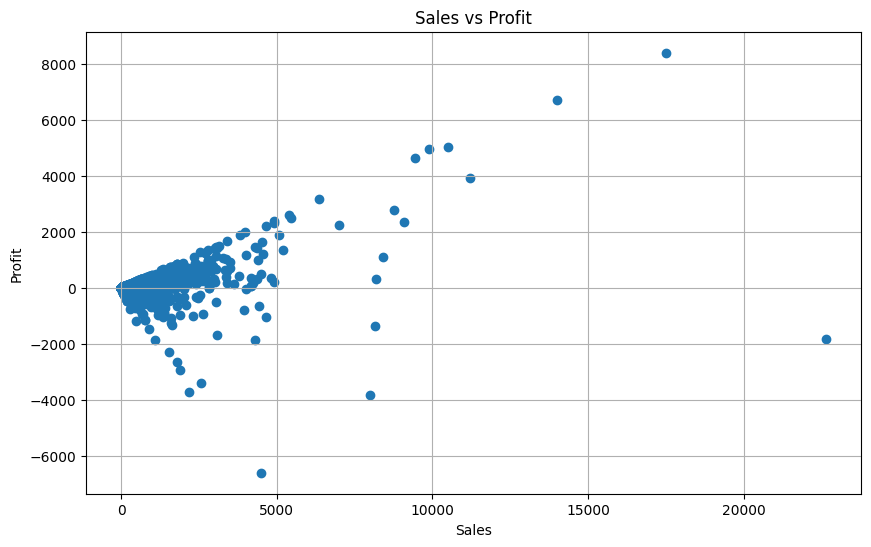

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Sales'],
    df['Profit']
)

plt.title('Sales vs Profit')

plt.xlabel('Sales')
plt.ylabel('Profit')

plt.grid(True)

plt.show()

# 📊 Business KPIs

- Total Sales
- Total Profit
- Average Monthly Sales
- Forecasted Growth
- Best Performing Category

# **Business Insights**


**Sales Trend**

The sales trend shows gradual growth over time.

**Forecast Analysis**

The model predicts continued sales growth for upcoming months.

**Business Benefits**

Businesses can use this forecast :

Manage inventory efficiently

* Reduce overstocking
* Prepare staffing req
* Improve revenue planning
* Avoid product shortages

# **Conclusion**

This project successfully predicts future sales using historical business data.
The forecasting model helps businesses understand future demand patterns and make better decisions.
